In [1]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [2]:
"""
Необходимо добавлять путь к библиотеки только в jupyter
"""
from os.path import dirname, abspath
path_library = dirname(abspath(".."))

try:
    from geotechnical_solutions.GeoSimModel.create_models.geology_models import *    # Путь к классу для создания геологии

except ModuleNotFoundError as ex:
    import sys
    sys.path.append(path_library)
    print("Добавление пути к библиотеки geotechnical_solutions")
    from geotechnical_solutions.GeoSimModel.create_models.geology_models import *
     
from geotechnical_solutions.GeoSimModel.create_models.foundation_models import *    # Путь к классу для создания сваи
from geotechnical_solutions.GeoSimModel.solve.building_analysis import *
from geotechnical_solutions.GeoSimModel import path_data    # Получить путь к табличным данным СП (нужно для расчетов)

Добавление пути к библиотеки geotechnical_solutions


# Тестовые варианты расчета осадки и ГСТ

In [46]:
def run_gst():
    """
    Создание материалов
    """
    for i, ige in enumerate(dict_ige):
        dict_ige[ige] = CreateMaterial()
        dict_ige[ige].change = ("E", E[i])
        dict_ige[ige].change = ("gamma", gamma[i])
    
    """
    Создание скважины
    """
    Borehole_1 = CreateBorehole(0, 0)
    
    """
    Создание слоев в скважине
    """
    for i, soil in enumerate(dict_soil):
        Borehole_1.createSoil(bot=z_soils[i + 1],
                              water=water_soils[i],
                              material=dict_ige[dict_soil[soil]]
                              )
    Borehole_1.change[0][0].change["Top"] = z_soils[0]
    
    """
    Создание нагрузки и плиты
    """
    load_1 = CreateLoad(Type="P", load=P)
    plate_1 = CreatePlate(FL=z_soils[0]-H_found, length=f_length, width=f_width)
    plate_1.change["Load"] = load_1

    """
    Вычисление напряжений
    """
    Mps = LayerSumMethod(Borehole_1,
                         plate_1,
                         load_1,
                         type_found=found
                         )
    
    Mps.setting(SP=2, step=0.2, round_value=4)
    Mps.calculation()

    print(f"осадка {Mps.Output()[0]}")
    print(f"ГСТ: {(z_soils[0] - H_found) - Mps.comparison()[0]}")
    print(f"Отметка и номер слоя: {Mps.comparison()}")

    return Mps


def plot_gst(Mps):

    result_dict = Mps.Output()[1]
    
    depth = []
    sigx = []
    sigy = []
    sigz = []
    alpha = []
    
    for key, item in result_dict.items():
        sigx.append(round(item[1]/1000,2))
        sigy.append(round(item[2]/1000,2))
        sigz.append(round(item[3]/1000,2))
        alpha.append(item[4])
        depth.append(float(key))
    
    
    plt.plot(sigx, depth, "-*", label="от грунта ниже FL")
    plt.plot(sigy, depth, "-*", label="Вертикальная нагрузка")
    plt.plot(sigz, depth, "-*", label="от грунта выше FL")
    plt.grid(True)
    plt.legend()
    plt.show()

## Тест 1

In [4]:
"""
Входные данные
"""
counts_ige = 3
dict_ige = {}
dict_soil = {}

for i in range(counts_ige):
    dict_ige[f"ige{i+1}"] = 0
    dict_soil[f"soil{i}"] = f"ige{i+1}"

E = [20e6, 30e6, 40e6]
gamma = [18e3, 19e3, 20e3]
z_soils = [30, 20, 10, 0]
water_soils = [False, False, False]

P = 500e3
H_found = 0
f_length = 2
f_width = 2

found = "прямоугольный"

In [5]:
Mps = run_gst()

осадка 0.035254
ГСТ: 4.800000000000001
Отметка и номер слоя: (25.2, 0)


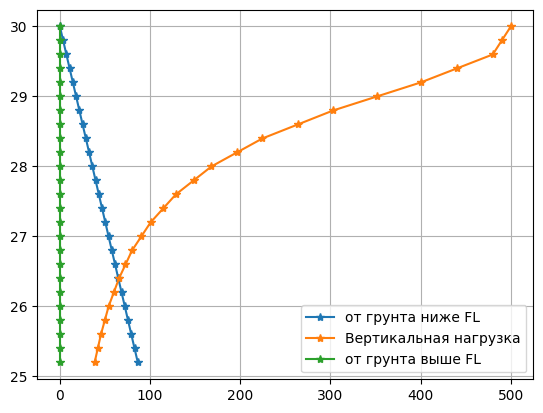

In [6]:
plot_gst(Mps)

## Тест 2

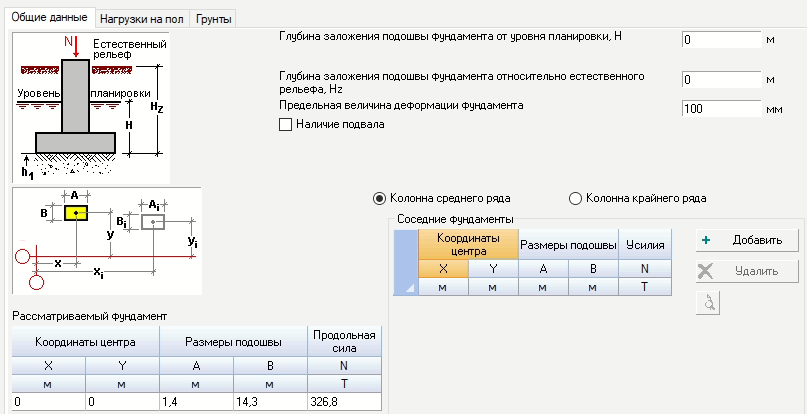
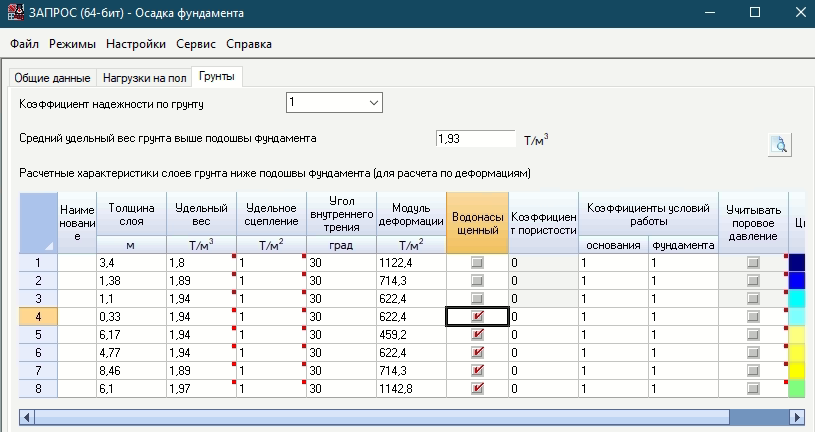
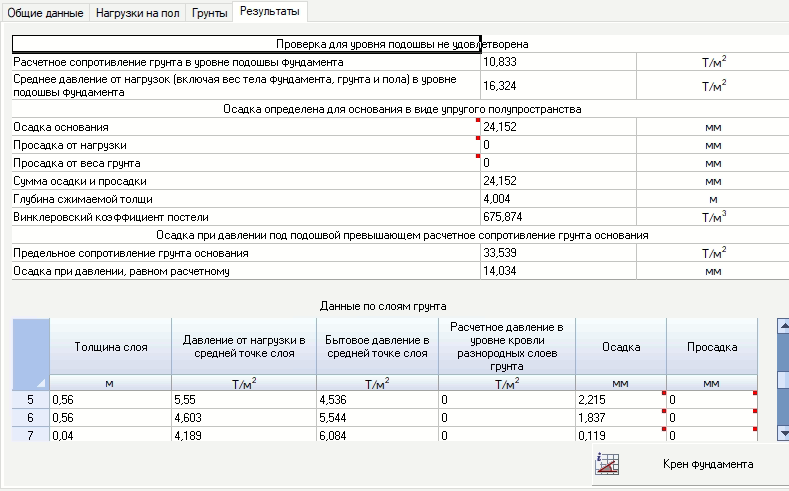

In [7]:
"""
Входные данные
"""
counts_ige = 7
dict_ige = {}
dict_soil = {}

for i in range(counts_ige):
    dict_ige[f"ige{i+1}"] = 0
    dict_soil[f"soil{i}"] = f"ige{i+1}"

E = [11e6, 7e6, 6.1e6, 4.5e6, 6.1e6, 7e6, 11.2e6]
gamma = [17640,
        18522,
        19012,
        19012,
        19012,
        18522,
        19306
        ]
z_soils = [130,
           126.6, 
           125.22, 
           124.12,
           117.62, 
           112.85, 
           104.39, 
           98.3
          ]

water_soils = [False,
               False,
               [123.79, 117.62],
               True,
               True,
               True,
               True
              ]
               

P = 160000
H_found = 0
f_length = 1.4
f_width = 14.3

found = "ленточный"

In [8]:
Mps = run_gst()

осадка 0.33578865342633524
ГСТ: 12.379999999999995
Отметка и номер слоя: (117.62, 3)


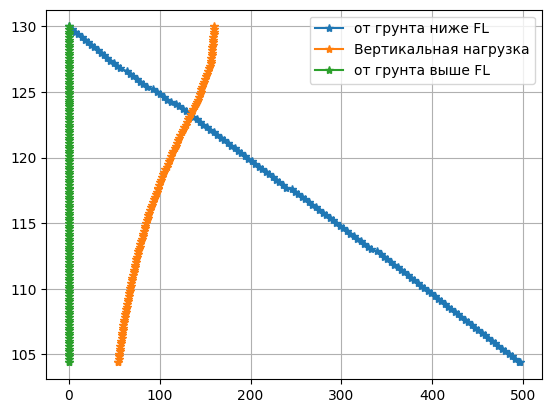

In [9]:
plot_gst(Mps)

## Тест 3

осадка 1.243126857142857
ГСТ: 16.700000000000003
Отметка и номер слоя: (113.3, 2)


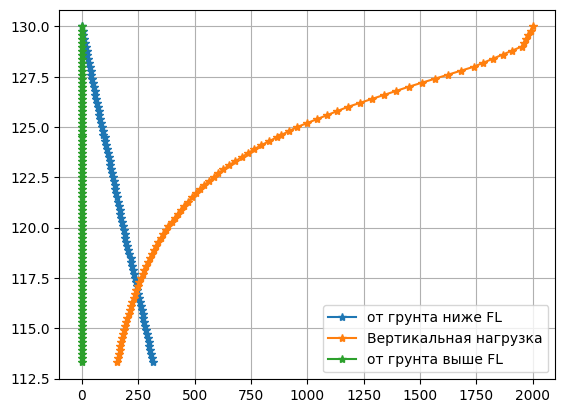

In [10]:
counts_ige = 4
dict_ige = {}
dict_soil = {}

for i in range(counts_ige):
    dict_ige[f"ige{i+1}"] = 0
    dict_soil[f"soil{i}"] = f"ige{i+1}"

E = [7e6, 12e6, 8e6, 10e6]
gamma = [17640,
        18522,
        19012,
        19012,
        ]
z_soils = [130,
           124.5, 
           124.5 - 6, 
           124.5 - 6 - 6.5,
           124.5 - 6 - 6.5 - 7, 
          ]

water_soils = [False,
               False,
               False,
               False,
              ]
               

P = 2e6
H_found = 0
f_length = 10
f_width = 5

found = "прямоугольный"

Mps = run_gst()
plot_gst(Mps)

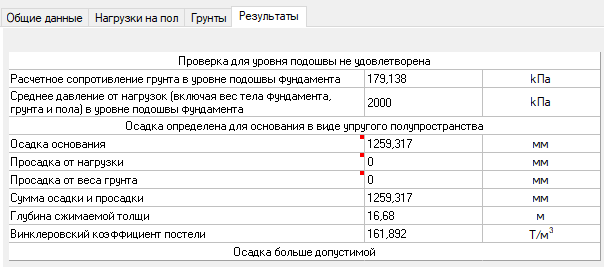
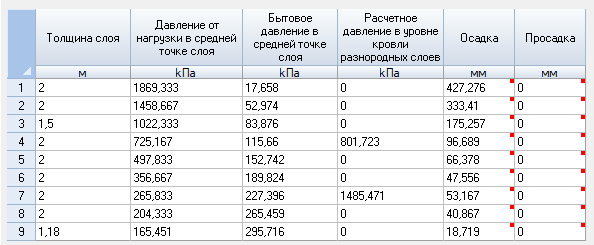

## Тест 4

осадка 0.030607734402844446
ГСТ: 5.0
Отметка и номер слоя: (119.5, 1)


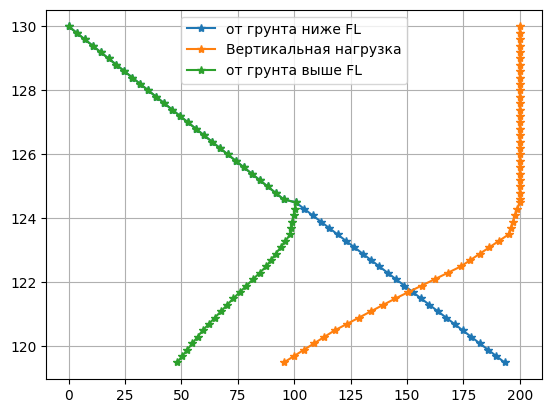

In [47]:
counts_ige = 4
dict_ige = {}
dict_soil = {}

for i in range(counts_ige):
    dict_ige[f"ige{i+1}"] = 0
    dict_soil[f"soil{i}"] = f"ige{i+1}"

E = [7e6, 12e6, 8e6, 10e6]
gamma = [17640,
        18522,
        19012,
        19012,
        ]
z_soils = [130,
           124.5, 
           124.5 - 6, 
           124.5 - 6 - 6.5,
           124.5 - 6 - 6.5 - 7, 
          ]

water_soils = [False,
               False,
               False,
               False,
              ]
               

P = 2e5
H_found = 5.5
f_length = 10
f_width = 5

found = "прямоугольный"

Mps = run_gst()
plot_gst(Mps)

In [43]:
result_dict = Mps.Output()[1]
depth = []
sigx = []
sigy = []
sigz = []
alpha = []

for key, item in result_dict.items():
    sigx.append(round(item[1]/1000,2))
    sigy.append(round(item[2]/1000,2))
    sigz.append(round(item[3]/1000,2))
    alpha.append(item[4])
    depth.append(float(key))

sigx = np.array(sigx)
sigy = np.array(sigy)
sigz = np.array(sigz)
depth = np.array(depth)
alpha = np.array(alpha)

In [44]:
np.where(sigx <= sigz)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28], dtype=int64),)

In [56]:
depth[28:], depth[33], depth[48]

(array([124.5, 124.3, 124.1, 123.9, 123.7, 123.5, 123.3, 123.1, 122.9,
        122.7, 122.5, 122.3, 122.1, 121.9, 121.7, 121.5, 121.3, 121.1,
        120.9, 120.7, 120.5, 120.3, 120.1, 119.9, 119.7, 119.5]),
 123.5,
 120.5)

In [40]:
sigx[28:] *.5
sigx[38]

137.77

In [53]:
sigy[33],sigy[38],sigy[48]

(195.07, 173.87, 117.87)

## Другое

In [ ]:
df_alpha = pd.read_excel(r'alpha.xlsx')
matrix = df_alpha.applymap(lambda x: float(str(x).replace(',', '.'))).to_numpy()

nu = 1
eps = 6.8


if nu >= 10:
    found='прямоугольный'

columns = ['eps', 'cycle', 1, 1.4, 1.8, 2.4, 3.2, 5, 'strip']

def interpol_alpha(eps, 
                   nu, 
                   type_found='прямоугольный'
                  ):
    
    eps_arr = matrix[:, 0]

    left = np.where((eps_arr <= eps))[0][-1]
    right = np.where((eps_arr >= eps))[0][0]

    if left == right:
        row_result = matrix[left, :]

    else:
        row_l = matrix[left, :]
        row_r = matrix[right, :]
        
        row_result = (row_r - row_l)/(row_r[0] - row_l[0]) * (eps - row_l[0]) + row_l
    
    if type_found == 'круглый':
        return row_result[1]
    
    if nu >= 10 or type_found == 'ленточный':
        return row_result[-1]

    nu_arr = np.array([1, 1.4, 1.8, 2.4, 3.2, 5, 10])
    left = np.where((nu_arr <= nu))[0][-1] + 2
    right = np.where((nu_arr >= nu))[0][0] + 2

    if nu_arr[left - 2] == nu_arr[right - 2]:
        return row_result[left]

    return (row_result[right] - row_result[left])/(nu_arr[right - 2] - nu_arr[left - 2]) * (nu - nu_arr[left - 2]) + row_result[left]
    
interpol_alpha(eps, nu)

In [ ]:
#z_list = [130, 124.5, 123.5, 116.3, 104.3]

z_list = [130,
           126.6, 
           125.2, 
           123.8,
           117.6, 
           112.8, 
           104.4, 
           98.3
          ]

def interpol_alpha(eps, 
                   nu, 
                   type_found='прямоугольный'
                  ):
    
    eps_arr = matrix[:, 0]

    left = np.where((eps_arr <= eps))[0][-1]
    right = np.where((eps_arr >= eps))[0][0]

    if left == right:
        row_result = matrix[left, :]

    else:
        row_l = matrix[left, :]
        row_r = matrix[right, :]
        
        row_result = (row_r - row_l)/(row_r[0] - row_l[0]) * (eps - row_l[0]) + row_l
    
    if type_found == 'круглый':
        return row_result[1]
    
    if nu >= 10 or type_found == 'ленточный':
        return row_result[-1]

    nu_arr = np.array([1, 1.4, 1.8, 2.4, 3.2, 5, 10])
    left = np.where((nu_arr <= nu))[0][-1] + 2
    right = np.where((nu_arr >= nu))[0][0] + 2

    if nu_arr[left - 2] == nu_arr[right - 2]:
        return row_result[left]

    return (row_result[right] - row_result[left])/(nu_arr[right - 2] - nu_arr[left - 2]) * (nu - nu_arr[left - 2]) + row_result[left]

def get_interval(z_list, step=.1):

    def get_count(num):
        x = num/step
        y = num//step
        if x - y >= .5:
           y+=1 
        return int(y)
    
    depth_all = np.array([0])
    z_depth = z_list[0] - np.array(z_list)

    for i in range(1, len(z_depth)):
        before = z_depth[i-1]
        after = z_depth[i]
        count = get_count(after - before)
        interval = np.linspace(before + step, after, count)
        
        depth_all = np.append(depth_all, interval)

    return depth_all

def get_interval_alpha(eps_list, nu, type_found='прямоугольный'):
    result = []
    for eps in eps_list:
        result.append(interpol_alpha(eps, nu, type_found))

    return np.array(result)


def get_sigzp(P, interval, nu, b):

    eps_list = 2 * interval / b

    alpha_list = get_interval_alpha(eps_list, nu)
    return alpha_list*P


def get_sigzg(interval, nu, b):

    eps_list = 2 * interval / b

    alpha_list = get_interval_alpha(eps_list, nu)
    return alpha_list*P


nu=11
b = 14.3

found = "ленточный"
sigzp = get_sigzp(160, get_interval(z_list), nu, b)
hi = get_interval(z_list)
hi

In [ ]:
nu_list = [1, 1.4, 1.8, 2.4, 3.2, 5, 10]

columns = ['eps', 'cycle', 1, 1.4, 1.8, 2.4, 3.2, 5, 'strip']

matrix = []

with open('alpha.txt', "r", encoding="utf-8") as f:
    for row, text in enumerate(f.readlines()):
        eps = round(0.4 * row, 1)
        text_list = text.split()
        
        text_list = list(map(lambda x: float(x.replace(',', '.')), text_list))

        matrix.append(text_list)

matrix = np.array(matrix)

nu = 3
eps = 1.4

interpol_alpha(eps, nu)

In [ ]:
"""
Входные данные
"""
counts_ige = 7
dict_ige = {}
dict_soil = {}

for i in range(counts_ige):
    dict_ige[f"ige{i+1}"] = 0
    dict_soil[f"soil{i}"] = f"ige{i+1}"

E = [11e6, 
     7e6, 
     6.1e6, 
     4.5e6, 
     6.1e6, 
     7e6, 
     11.2e6
    ]
gamma = [17640,
        18522,
        19012,
        19012,
        19012,
        18522,
        19306
        ]
z_list = [130,
           126.6, 
           125.2, 
           123.8,
           117.6, 
           112.8, 
           104.4, 
           98.3
          ]

water_soils = [False,
               False,
               False,
               False,
               False,
               False,
               False
              ]
               

P = 160000
H_found = 0
f_length = 1.4
f_width = 14.3

found = "ленточный"

In [ ]:
"""
Создание материалов
"""
for i, ige in enumerate(dict_ige):
    dict_ige[ige] = CreateMaterial()
    dict_ige[ige].change = ("E", E[i])
    dict_ige[ige].change = ("gamma", gamma[i])

"""
Создание скважины
"""
Borehole_1 = CreateBorehole(0, 0)

"""
Создание слоев в скважине
"""
for i, soil in enumerate(dict_soil):
    Borehole_1.createSoil(bot=z_soils[i + 1],
                          water=water_soils[i],
                          material=dict_ige[dict_soil[soil]]
                          )
Borehole_1.change[0][0].change["Top"] = z_soils[0]

"""
Создание нагрузки и плиты
"""
load_1 = CreateLoad(Type="P", load=P)
plate_1 = CreatePlate(FL=z_soils[0]-H_found, length=f_length, width=f_width)
plate_1.change["Load"] = load_1

In [ ]:
"""
Вычисление напряжений
"""
Mps = LayerSumMethod(Borehole_1,
                     plate_1,
                     load_1,
                     type_found=found,
                     path_alpha = path_data+r"alpha.txt"
                     )

#Mps.round_value = 1

Mps.setting(step=.1, round_value=2)
Mps.calculation()

In [ ]:
print(f"осадка {Mps.Output()[0]}")
print(f"ГСТ: {(z_soils[0] - H_found) - Mps.comparison()[0]}")
print(f"Отметка и номер слоя: {Mps.comparison()}")

In [ ]:
result_dict = Mps.Output()[1]
depth = []
sigx = []
sigy = []
sigz = []
alpha = []

for key, item in result_dict.items():
    sigx.append(round(item[1]/1000,2))
    sigy.append(round(item[2]/1000,2))
    sigz.append(round(item[3]/1000,2))
    alpha.append(item[4])
    depth.append(float(key))


plt.plot(sigx, depth, "-*", label="фундамент")
plt.plot(sigy, depth, "-*", label="грунт")
plt.plot(sigz, depth, "-*", label="sigz")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
import numpy as np
sigx = np.array(sigx)
sigy = np.array(sigy)
depth = np.array(depth)
alpha = np.array(alpha)

In [ ]:
alpha

In [ ]:
-depth[65:70]+130

In [ ]:
hi.shape, depth.shape

In [ ]:
np.where(depth[:-1] - depth[1:] < .09)

In [ ]:
-depth[[ 34, 35,  49, 50,  64, 65, 127,128, 176,177]]+130

In [ ]:
hi[[ 34, 35,  49, 50,  64, 65, 127,128, 176,177]]

In [ ]:
sigy[65:70]

In [ ]:
sigzp[65:70]

In [ ]:
from decimal import Decimal

x = 0.0

step = 0.01
error = 0.0

y = Decimal('0.0')

for _ in range(100):
    # Корректируем шаг с учётом накопленной ошибки
    new_x = x + (step + error)
    error = (x - new_x) + (step + error)  # Корректируем ошибку
    x = new_x
    y+=Decimal('0.01')
    
    print(y, x)